In [7]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
import pandas as pd
import seaborn as sns




In [8]:
def gsa_heat_custom(order_effects,
             xlabels, 
             ylabels, 
             savepath, 
             figname="heatmap_gsa",
             title="Total order effects",
             height=10,
             width=10, 
             cbar_shift=None,
             cbar_width=10,
             fontsize=16):

    """
    Plots a heatmap for a global sensitivity analysis.

    Args:
        - order_effects: first or total order effects matrix 
        - xlabels: parameter names
        - ylabels: output names
        - savepath: where to save the figure
        - height: figure height
        - width: figure width
        - correction: if you want to get rid of very small effects (below 0.01)
        - cbar_shift: shift to apply to the colorbar
        - cbar_width: how wide should your colorbar be (set to 0 to get rid of the colorbar)
        - xlabels_latex: latex parameter names - for paper plotting
        - ylabels_latex: latex output names - for paper plotting
        - fontsize: size of figure font

    """

    order_effects = order_effects / np.sum(order_effects, axis=0)

    plt.rc('text', usetex=False)

    if cbar_shift is None:
        cbar_shift = 0.0

    fig, axes = plt.subplots(figsize=(width, height))
    df = pd.DataFrame(data=np.transpose(order_effects), index=ylabels, columns=xlabels)

    rot_angle_x = 90
    rot_angle_y = 0
    cbar_size = 0.8
    cbar_orientation = "vertical"

    h1 = sns.heatmap(
        df,
        cmap="rocket_r",
        vmin=0.0,
        vmax=1.0,
        square=True,
        linewidth=0.5,
        linecolor='black',
        cbar=False,
        ax=axes,
    )

    if cbar_width > 0:
        divider = make_axes_locatable(axes)
        cax = divider.append_axes("right", size="2.5%", pad=0.1)

        cbar = fig.colorbar(h1.get_children()[0], cax=cax, orientation="vertical", shrink=cbar_size)
        cbar.outline.set_visible(False)
        cbar.set_label("$ST$", fontsize=fontsize, rotation=-90, labelpad=10)
        cbar.set_ticks([0, 1])
        cbar.ax.set_yticklabels(['0', '1'], fontsize=fontsize)
        cbar.ax.tick_params(size=0)  # Remove tick marks

    h1.set_xticks(np.arange(df.shape[1]) + 0.5)
    h1.set_yticks(np.arange(df.shape[0]) + 0.5)
    axes.set_title(title, fontsize=fontsize+5, fontweight="bold", pad=30)  # Increase space below the title
    axes.tick_params(left=False, bottom=False)

    h1.set_xticklabels(xlabels, rotation=rot_angle_x, va="top", fontsize=fontsize)
    h1.set_yticklabels(ylabels, rotation=rot_angle_y, ha="right", fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(f"{savepath}/{figname}.png", bbox_inches="tight", dpi=300)


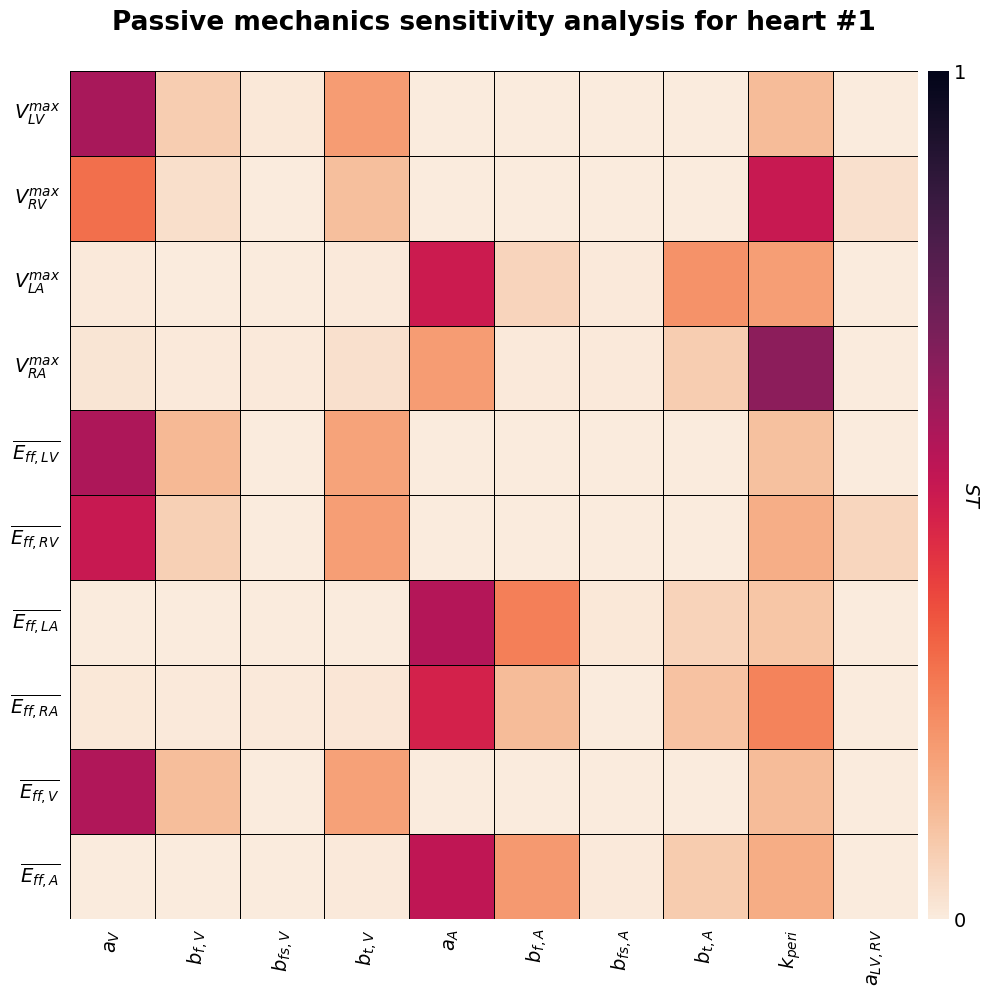

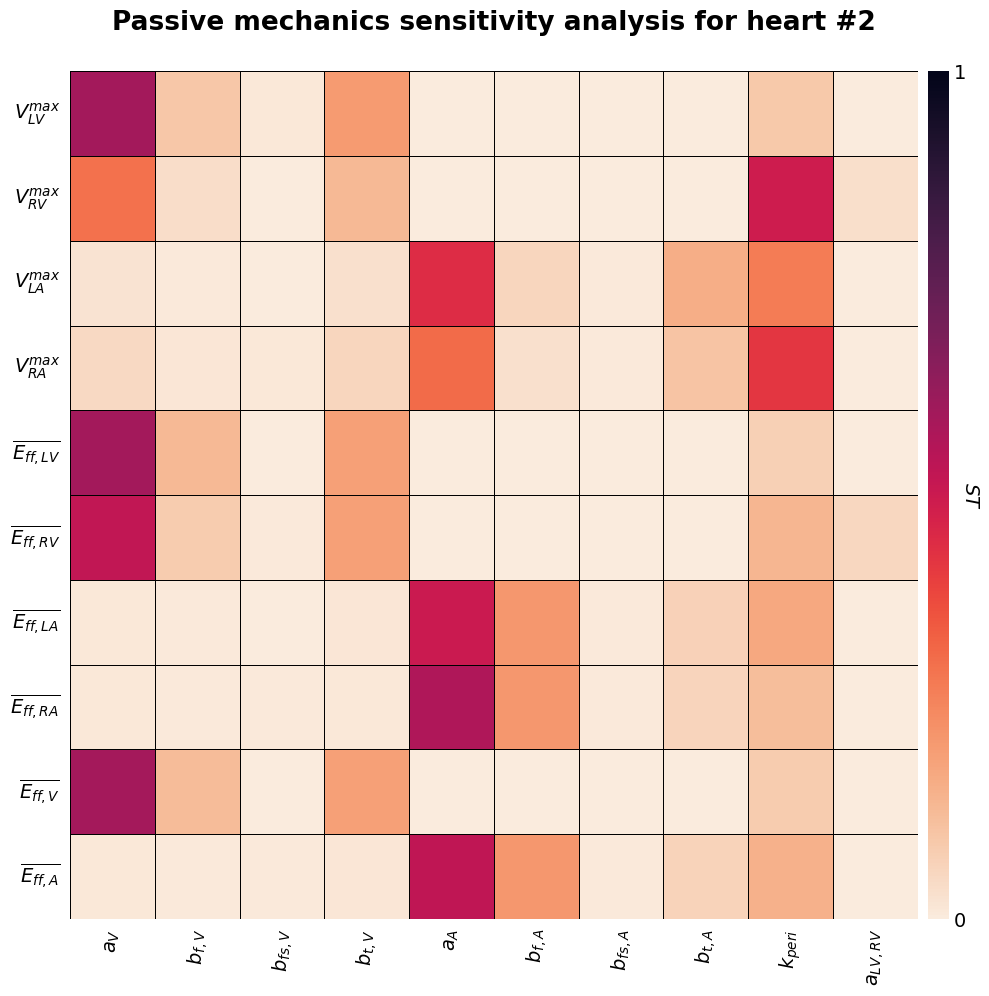

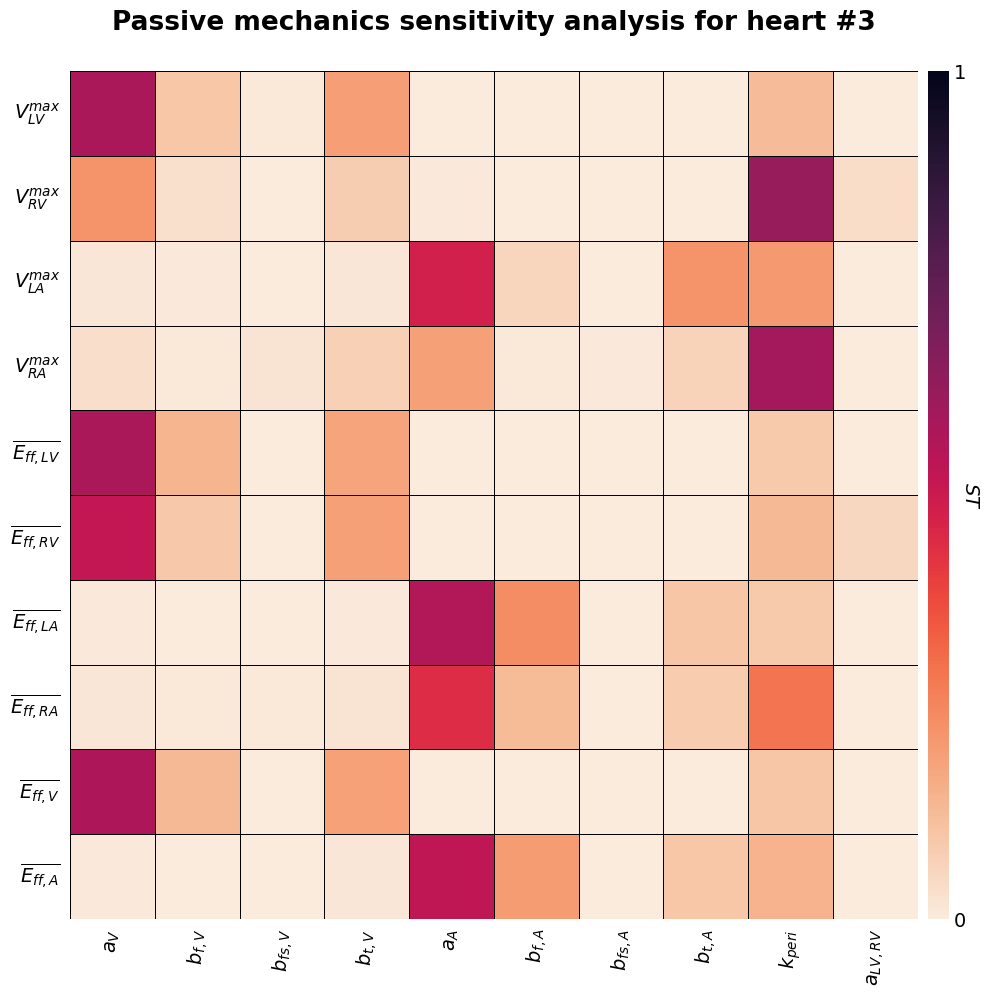

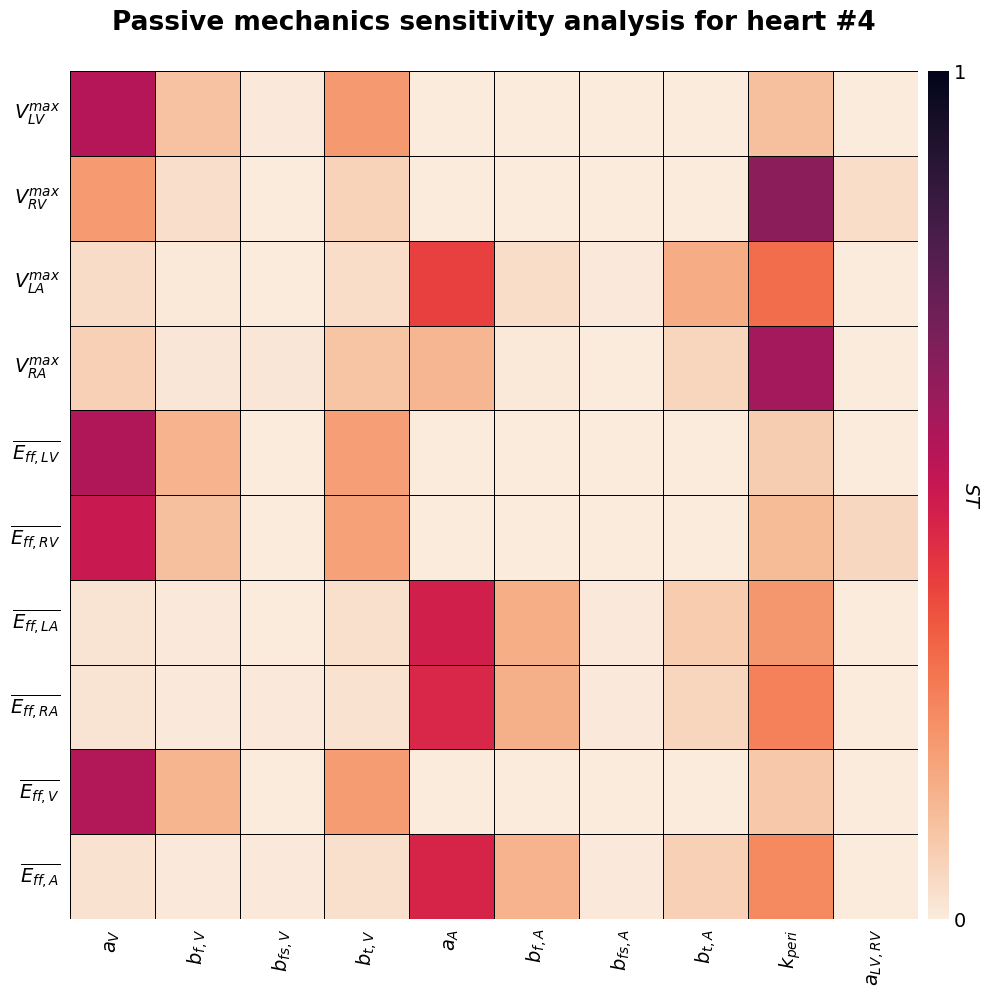

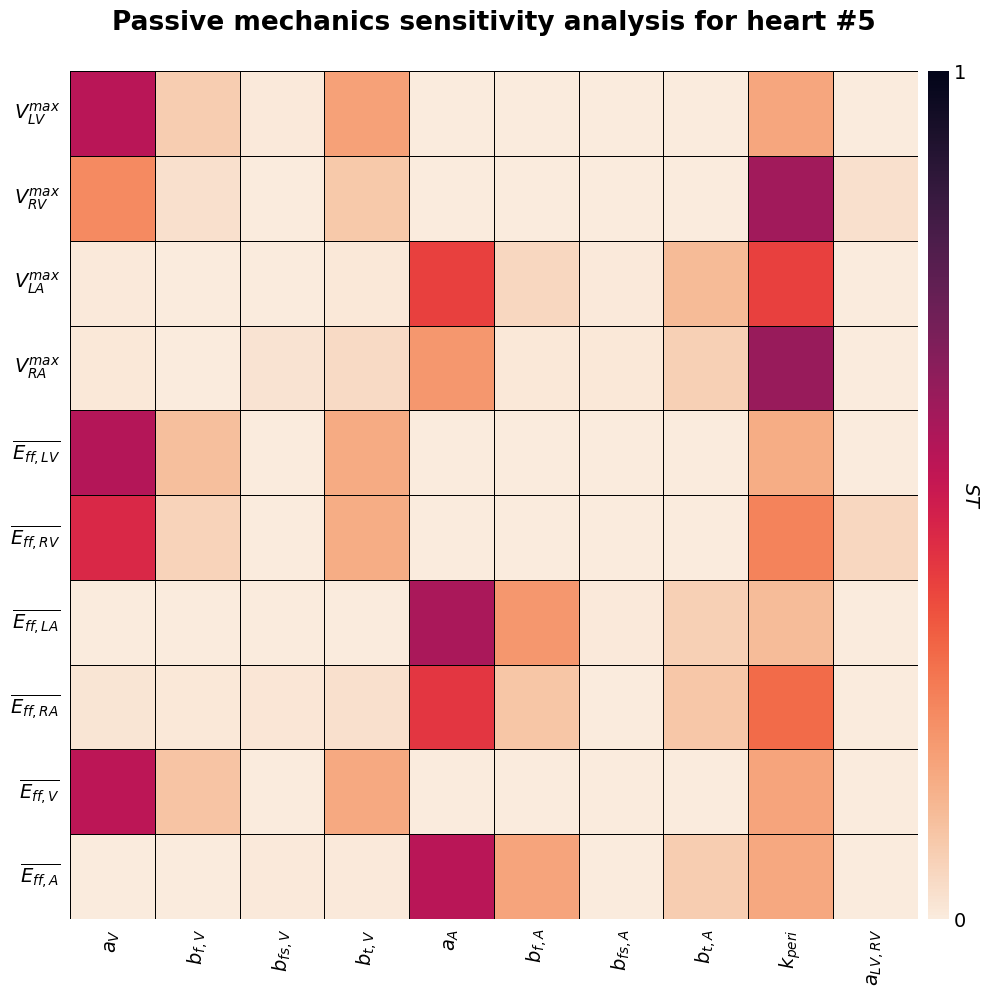

In [9]:
heart_names = ["10EA03323", "10KM01952", "10GH00962", "10KH00011", "10RB00080"]
scenario_numbers = {"EP": [17, 21, 19, 13, 14],
                    "inflation": [22, 25, 23, 24, 26]}

for i in range(len(heart_names)):
	case_name = heart_names[i]
	scenario_number = scenario_numbers["inflation"][i]

	scenario = f"HCM/{case_name}/scenarios/{scenario_number}"

	# Read Si_total.csv and convert to numpy array of floats
	with open(f"/media/croderog/SeagateExpansionDrive/{scenario}/output/Si_total.csv", 'r') as f:
		csv_reader = csv.reader(f)
		ST_all = np.array([list(map(float, row)) for row in csv_reader])

	if os.path.isfile(f"/media/croderog/SeagateExpansionDrive/{scenario}/data/xlabels_plot.txt"):
		xlabels = np.loadtxt(f"/media/croderog/SeagateExpansionDrive/{scenario}/data/xlabels_plot.txt", dtype=str)
	else:
		xlabels = np.loadtxt(f"/media/croderog/SeagateExpansionDrive/{scenario}/data/xlabels.txt", dtype=str)
	if os.path.isfile(f"/media/croderog/SeagateExpansionDrive/{scenario}/data/ylabels_plot.txt"):
		ylabels = np.loadtxt(f"/media/croderog/SeagateExpansionDrive/{scenario}/data/ylabels_plot.txt", dtype=str)
	else:
		ylabels = np.loadtxt(f"/media/croderog/SeagateExpansionDrive/{scenario}/data/ylabels.txt", dtype=str)

	plotpath=f"/media/croderog/SeagateExpansionDrive/{scenario}/figures/"

	os.makedirs(plotpath, exist_ok=True)

	gsa_heat_custom(order_effects = ST_all, 
					title=f"Passive mechanics sensitivity analysis for heart #{i+1}",
					xlabels=xlabels, 
					ylabels=ylabels, 
					fontsize=14,
					savepath=plotpath, 
					figname=f"inflation_heatmap_GSA_{i+1}",
					height=10,
					cbar_width=6)


# Radar charts to compare GSAs

In [10]:
import csv
import matplotlib.pyplot as plt
import numpy as np



def plot_GSA_radar_chart(scenarios, xlabels, ylabels, savepath, fontsize,figname_preffix):

    for output_idx in range(len(ylabels)):
        figname = f"{figname_preffix}_{output_idx}"

        theta = xlabels
        theta_radians = np.linspace(0, 2 * np.pi, len(theta), endpoint=False).tolist()
        theta_radians += theta_radians[:1]

        r = np.zeros((len(scenarios), len(theta)))


        for i, scenario in enumerate(scenarios):
            # Read Si_total.csv and convert to numpy array of floats
            with open(f"/media/croderog/SeagateExpansionDrive/HCM/{scenario}/output/Si_total.csv", 'r') as f:
                csv_reader = csv.reader(f)
                ST_all = np.array([list(map(float, row)) for row in csv_reader])

            order_effects = ST_all[:,output_idx]
            order_effects = order_effects / np.sum(order_effects)

            r[i] = order_effects
            
        r = np.concatenate((r, r[:, :1]), axis=1)
        # Define colorblind-safe colors
        # colors = ['#377eb8', '#ff7f00', '#4daf4a',
        #                 '#f781bf', '#a65628', '#984ea3',
        #                 '#999999', '#e41a1c', '#dede00']

        # Curran et al's colours
        colors = ['#4fcdba', '#e662ad', '#f7c26f', '#6ecb74', '#173263']

        # Create polar plot
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

        for i, scenario in enumerate(scenarios):
            ax.plot(theta_radians, r[i], marker='.', label=f"Heart #{i+1}", color=colors[i])

# Set theta ticks and labels
        ax.set_xticks(theta_radians[:-1])
        ax.set_xticklabels(theta, fontsize=fontsize)
        ax.xaxis.set_tick_params(which="major", pad=10)

        ax.set_rmax(1)

        title = f"{ylabels[output_idx]}"
        if title.startswith("$"):
            title = f"$\mathbf{{{title[1:-1]}}}$"

        plt.title(title, fontsize=fontsize+5, fontweight="bold", pad=30)
        plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.2))

        plt.tight_layout()
        plt.savefig(f"{savepath}/{figname}.png", bbox_inches="tight", dpi=300)

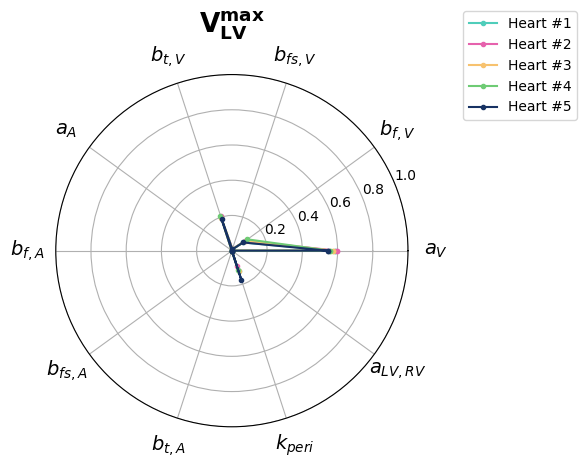

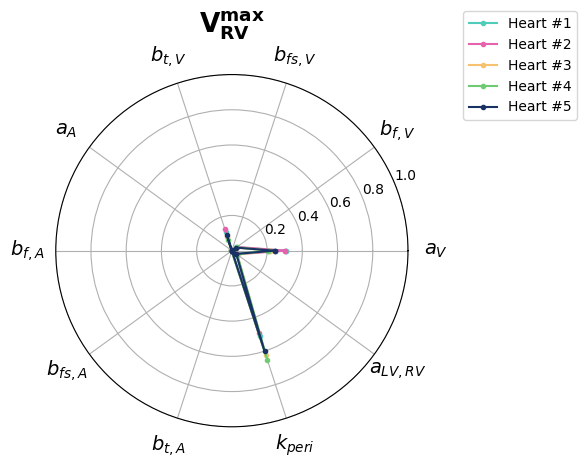

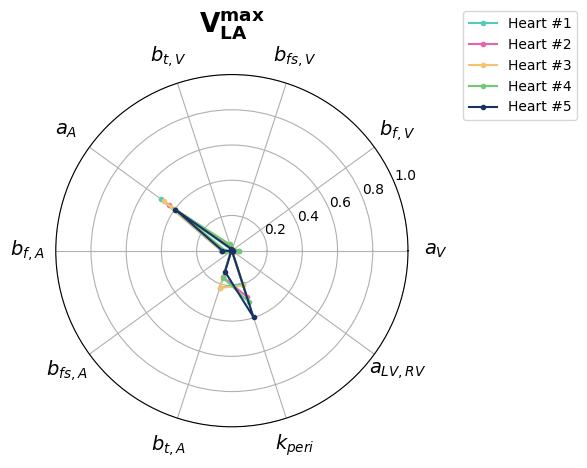

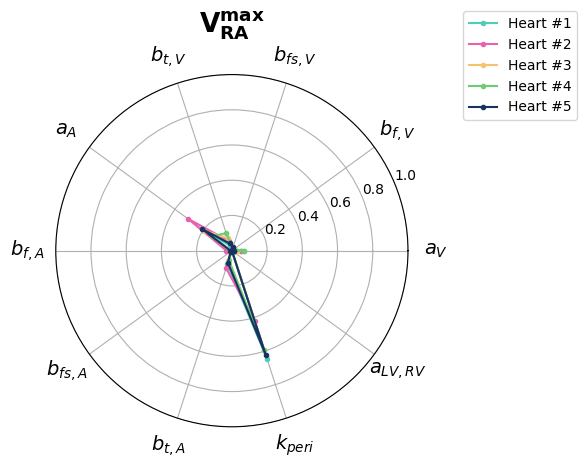

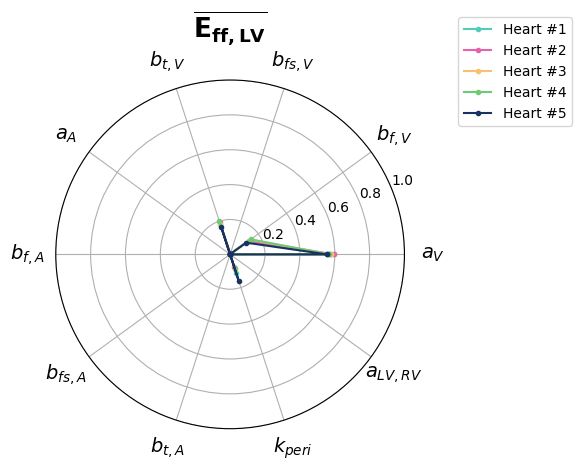

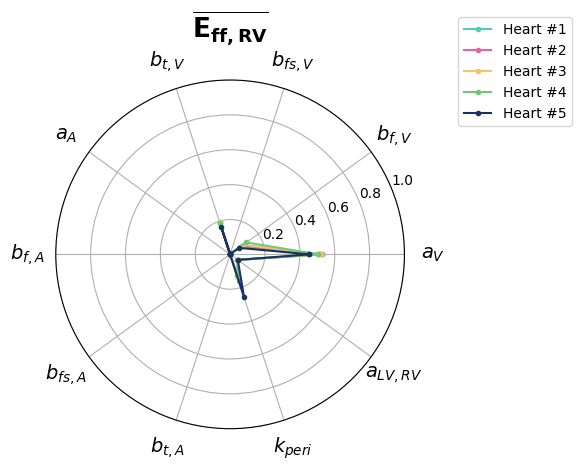

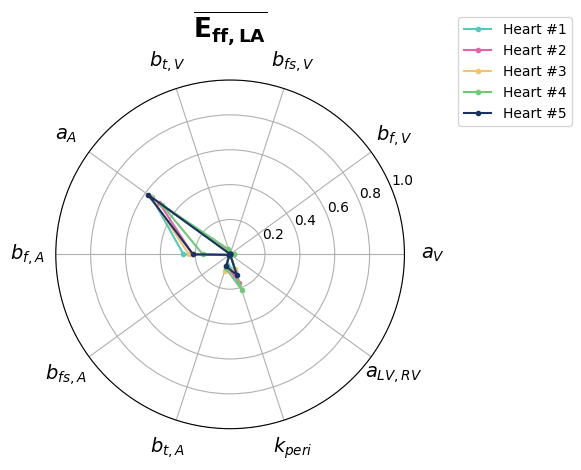

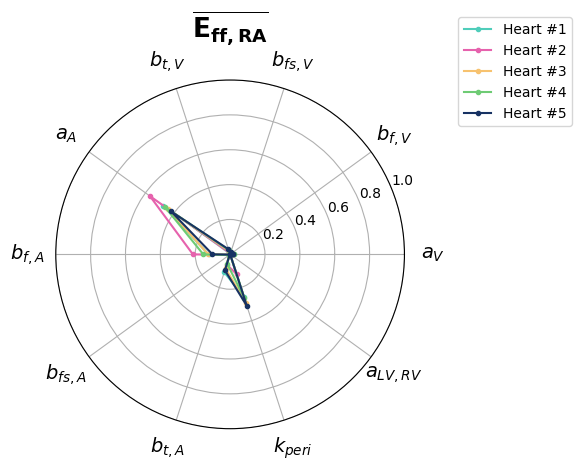

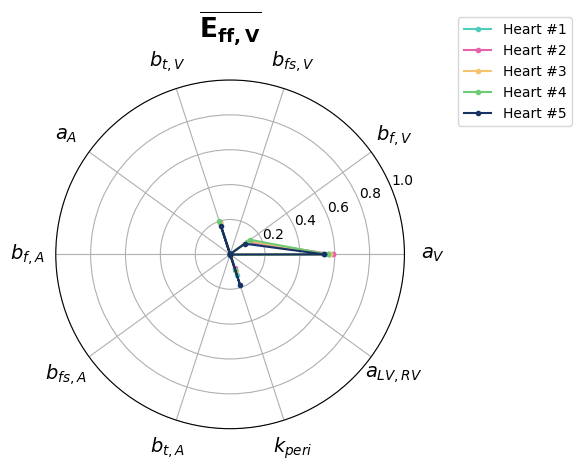

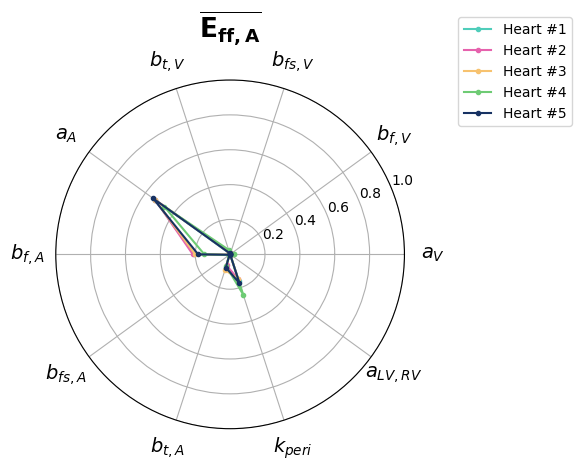

In [11]:
# scenarios = [
#     # "10EA03323/scenarios/17/",
#             #  "10GH00962/scenarios/19/",
#              "10KH00011/scenarios/13/",
#             #  "10KM01952/scenarios/20/",
#              "10RB00080/old_iteration/scenarios/14",
#              ]

scenarios = [f"{heart_names[i]}/scenarios/{scenario_numbers['inflation'][i]}" for i in range(len(heart_names))]

xlabels = np.loadtxt(f"/media/croderog/SeagateExpansionDrive/HCM/{scenarios[-1]}/data/xlabels_plot.txt", dtype=str)
ylabels = np.loadtxt(f"/media/croderog/SeagateExpansionDrive/HCM/{scenarios[-1]}/data/ylabels_plot.txt", dtype=str)
savepath = f"/media/croderog/SeagateExpansionDrive/HCM/figures"

fontsize=14
figname_preffix = "inflation_GSA_radarchart"

plot_GSA_radar_chart(scenarios=scenarios,
					 xlabels=xlabels,
					 ylabels=ylabels,
					 savepath=savepath,
					 fontsize=fontsize,
					 figname_preffix=figname_preffix)

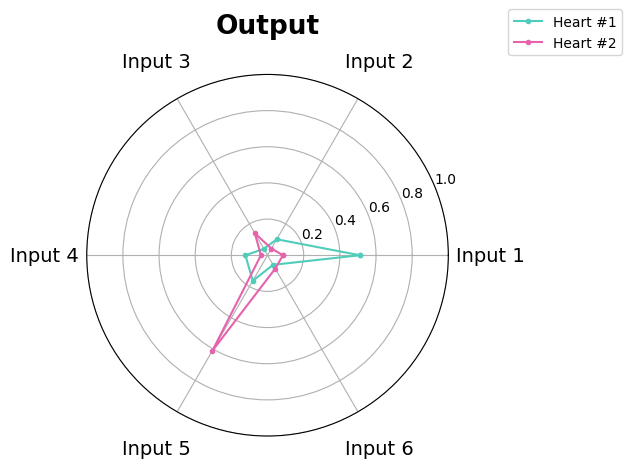

In [12]:
import numpy as np
import matplotlib.pyplot as plt

xlabels = ["Input 1", "Input 2", "Input 3", "Input 4", "Input 5", "Input 6"]
ylabels = "Output"
savepath = "/media/croderog/SeagateExpansionDrive/HCM/figures"

fontsize = 14
figname = "template_GSA_radarchart"

theta = xlabels
theta_radians = np.linspace(0, 2 * np.pi, len(theta), endpoint=False).tolist()
# Close the circle
theta_radians += theta_radians[:1]

r1 = [1, 0.2, 0.08, 0.24, 0.32, 0.12]
r2 = [0.14, 0.07, 0.23, 0.06, 1, 0.14]

r = np.array([[i/sum(r1) for i in r1],
              [i/sum(r2) for i in r2]])
# Close the circle
r = np.concatenate((r, r[:, :1]), axis=1)

# Define colorblind-safe colors
# colors = ['#377eb8', '#ff7f00', '#4daf4a',
#                 '#f781bf', '#a65628', '#984ea3',
#                 '#999999', '#e41a1c', '#dede00']

# Curran et al's colours
colors = ['#4fcdba', '#e662ad']

# Create polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

for i in range(2):
    ax.plot(theta_radians, r[i], marker='.', label=f"Heart #{i+1}", color=colors[i])

# Set theta ticks and labels
ax.set_xticks(theta_radians[:-1])
ax.set_xticklabels(theta, fontsize=fontsize)
ax.xaxis.set_tick_params(which="major", pad=20)

ax.set_rmax(1)

title = f"{ylabels}"
if title.startswith("$"):
    title = f"$\mathbf{{{title[1:-1]}}}$"

plt.title(title, fontsize=fontsize + 5, fontweight="bold", pad=30)
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.2))

plt.tight_layout()
plt.savefig(f"{savepath}/{figname}.png", bbox_inches="tight", dpi=300)
